In [91]:
#https://drive.google.com/file/d/1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W/view?usp=share_link
!gdown 1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W

Downloading...
From: https://drive.google.com/uc?id=1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W
To: /content/train_loan_imbalanced.csv
100% 38.0k/38.0k [00:00<00:00, 65.0MB/s]


In [92]:
import pandas as pd
df = pd.read_csv('/content/train_loan_imbalanced.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [93]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split
seed = 42

In [94]:
df.drop('Loan_ID', axis=1, inplace=True)
df.shape

(614, 12)

In [95]:
df.isna().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [96]:
df.dropna(inplace=True, axis=0)
print(df.shape)

(480, 12)


In [97]:
# Convert 'Dependents' to numeric by replacing '3+' with 3 and then casting to int
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

# Convert 'Loan_Status' to numeric (0 for 'N', 1 for 'Y')
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Identify remaining object columns for one-hot encoding
object_cols = df.select_dtypes(include=['object']).columns

# Apply one-hot encoding to the remaining categorical columns
df = pd.get_dummies(df, columns=object_cols, drop_first=True)

print("DataFrame after converting all values to numeric:")
print(df.head())
print("\nDataFrame Info:")
df.info()

DataFrame after converting all values to numeric:
   Dependents  ApplicantIncome  CoapplicantIncome  LoanAmount  \
1           1             4583             1508.0       128.0   
2           0             3000                0.0        66.0   
3           0             2583             2358.0       120.0   
4           0             6000                0.0       141.0   
5           2             5417             4196.0       267.0   

   Loan_Amount_Term  Credit_History  Loan_Status  Gender_Male  Married_Yes  \
1             360.0             1.0            0         True         True   
2             360.0             1.0            1         True         True   
3             360.0             1.0            1         True         True   
4             360.0             1.0            1         True        False   
5             360.0             1.0            1         True         True   

   Education_Not Graduate  Self_Employed_Yes  Property_Area_Semiurban  \
1                

In [98]:
y = df['Loan_Status']
X = df.drop('Loan_Status', axis=1)
print(X.shape, y.shape)

(480, 12) (480,)


In [99]:
X['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
3,41


In [100]:
tmp = X.select_dtypes(include=["object_"])
cols = tmp.columns
catList = [df.columns.get_loc(c) for c in cols if c in df]
catList # voila!

[]

In [101]:
sm = SMOTENC(categorical_features = [0,7,8,9,10,11], random_state=42)
X_res, y_res = sm.fit_resample(X, y)

In [102]:
model = LogisticRegression(random_state=seed,max_iter=10000)
model.fit(X_res, y_res)

LogisticRegression(max_iter=10000, random_state=42)

In [104]:
# Perform train-test split using the already preprocessed X and y
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.20, random_state=seed)

# Define the categorical features for SMOTENC based on the current X_train columns:
# 0: Dependents (int, categorical)
# 5: Credit_History (float, categorical 0.0/1.0)
# 6: Gender_Male (bool, categorical)
# 7: Married_Yes (bool, categorical)
# 8: Education_Not Graduate (bool, categorical)
# 9: Self_Employed_Yes (bool, categorical)
# 10: Property_Area_Semiurban (bool, categorical)
# 11: Property_Area_Urban (bool, categorical)
categorical_features_indices = [0, 5, 6, 7, 8, 9, 10, 11]

sm = SMOTENC(categorical_features=categorical_features_indices, random_state=seed)
X_res, y_res = sm.fit_resample(X_train, Y_train)

print("Shape after SMOTENC:", X_res.shape, y_res.shape)
print("Class distribution after SMOTENC:\n", pd.Series(y_res).value_counts())

model = LogisticRegression(random_state=seed, max_iter=10000)
model.fit(X_res, y_res)

predictions_Smote = model.predict(X_test)
print("Predictions generated successfully.")

Shape after SMOTENC: (528, 12) (528,)
Class distribution after SMOTENC:
 Loan_Status
0    264
1    264
Name: count, dtype: int64
Predictions generated successfully.


In [105]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
class_Smote = classification_report(predictions_Smote,Y_test)
print(class_Smote)
confuse_Smote = confusion_matrix(predictions_Smote,Y_test)
print(confuse_Smote)

              precision    recall  f1-score   support

           0       0.61      0.63      0.62        27
           1       0.85      0.84      0.85        69

    accuracy                           0.78        96
   macro avg       0.73      0.74      0.73        96
weighted avg       0.78      0.78      0.78        96

[[17 10]
 [11 58]]


In [106]:
!pip install pulp # for partial dependence plots!
!pip install pycebox
from pycebox.ice import ice, ice_plot

  Preparing metadata (setup.py) ... done
  Created wheel for pycebox: filename=pycebox-0.0.1-py3-none-any.whl size=3661 sha256=8a2bce2f62f190edb6a095c023fa2842949de47d7a34272071a417e210b5a92a
  Stored in directory: /root/.cache/pip/wheels/8b/17/c3/6e09db937db8dcb4a43caabbea110f67a6d17f464050eb12c1
Successfully built pycebox


In [107]:
from sklearn.inspection import permutation_importance

/tmp/ipykernel_2015/3937084572.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(result.importances[perm_sorted_idx].T, vert=False,


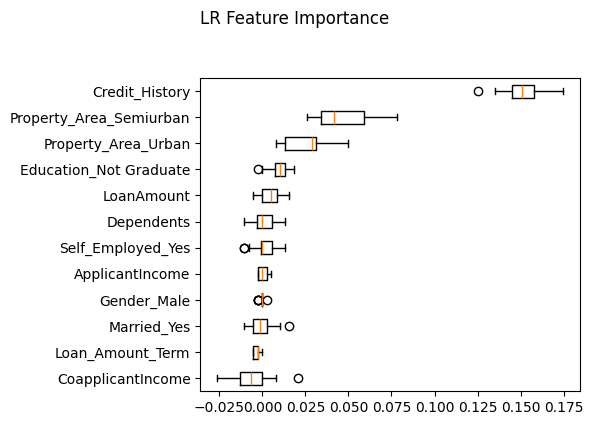

In [112]:
clf = model

result = permutation_importance(clf, X_train, Y_train, n_repeats=20,
                                random_state=42)
perm_sorted_idx = result.importances_mean.argsort()

fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))
ax1.boxplot(result.importances[perm_sorted_idx].T, vert=False,
            labels=X.columns[perm_sorted_idx])
fig.suptitle('LR Feature Importance', y=1.05) # don't forget to update title!
fig.tight_layout()
plt.show()

In [117]:
top5_features = perm_sorted_idx[7:]
top5_features = X.columns[top5_features]
print(top5_features)

Index(['LoanAmount', 'Education_Not Graduate', 'Property_Area_Urban',
       'Property_Area_Semiurban', 'Credit_History'],
      dtype='object')


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


(163, 384)


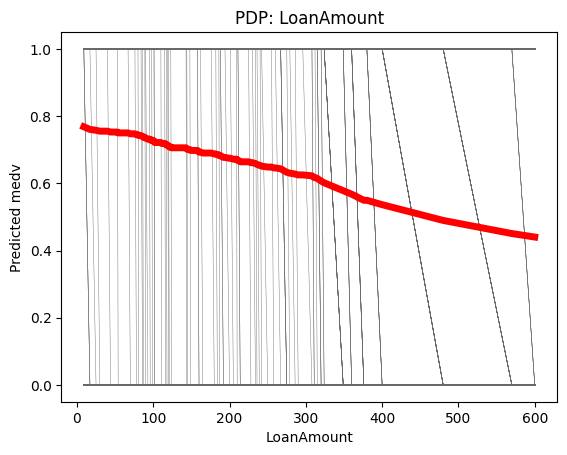

In [120]:
tmpdf = ice(data=X_train, # ice needs a dataframe
            column='LoanAmount', # the column name
                   predict=model.predict) # the predict statement from the
                                          # model
print(np.shape(tmpdf))
ice_plot(tmpdf, c='dimgray', linewidth=0.3,
                  plot_pdp=True,
         pdp_kwargs={'linewidth': 5, 'color':'red'})
plt.title('PDP: LoanAmount')
plt.ylabel('Predicted medv')
plt.xlabel('LoanAmount');
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


(2, 384)


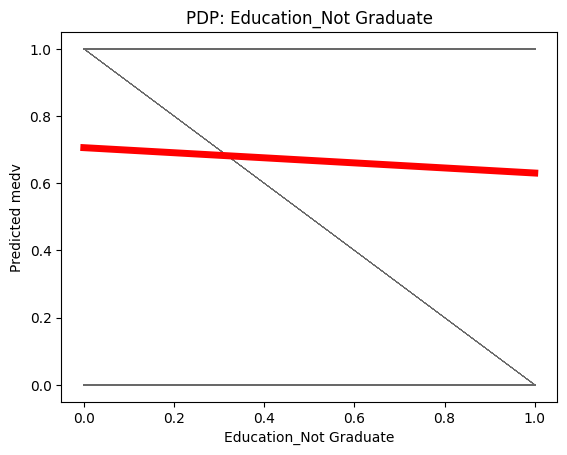

In [123]:
tmpdf = ice(data=X_train, # ice needs a dataframe
            column='Education_Not Graduate', # the column name
                   predict=model.predict) # the predict statement from the
                                          # model
print(np.shape(tmpdf))
ice_plot(tmpdf, c='dimgray', linewidth=0.3,
                  plot_pdp=True,
         pdp_kwargs={'linewidth': 5, 'color':'red'})
plt.title('PDP: Education_Not Graduate')
plt.ylabel('Predicted medv')
plt.xlabel('Education_Not Graduate');
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


(2, 384)


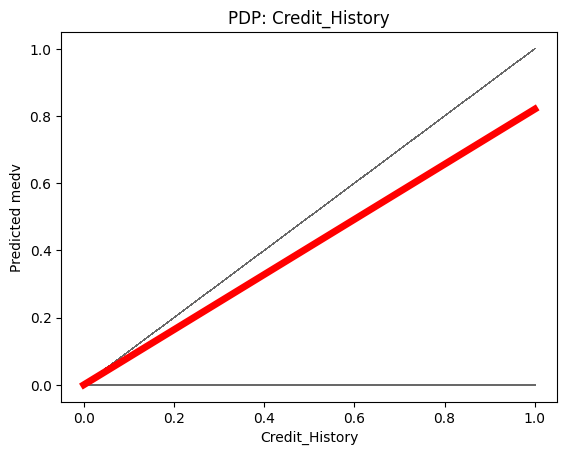

In [122]:
tmpdf = ice(data=X_train, # ice needs a dataframe
            column='Credit_History', # the column name
                   predict=model.predict) # the predict statement from the
                                          # model
print(np.shape(tmpdf))
ice_plot(tmpdf, c='dimgray', linewidth=0.3,
                  plot_pdp=True,
         pdp_kwargs={'linewidth': 5, 'color':'red'})
plt.title('PDP: Credit_History')
plt.ylabel('Predicted medv')
plt.xlabel('Credit_History');
plt.show()